In [1]:
# -*- coding: utf-8 -*-
"""
Time‑Series Cross‑Validation with Optuna for CatBoost
Predicts churn_status (not_churned / invol_churn / vol_churn)
"""

import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, accuracy_score, log_loss
import optuna
from optuna.samplers import TPESampler

# ------------------------------
# 1. Load and prepare data
# ------------------------------
df = pd.read_csv('train_data/train_full_with_generations_v2.csv')


print("Shape:", df.shape)

# Convert subscription_start_date to datetime (order is preserved)
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'])

# Sort chronologically – essential for TimeSeriesSplit
df_sorted = df.sort_values('subscription_start_date').reset_index(drop=True)
print(f"Date range: {df_sorted['subscription_start_date'].min()} → {df_sorted['subscription_start_date'].max()}")

# Define categorical features (as per your final selection)
cat_cols = ['subscription_plan', 'country_code', 'source', 'first_feature', 'role', 'team_size']

# Fill missing categorical values with 'missing' and convert to string
for col in cat_cols:
    df_sorted[col] = df_sorted[col].astype(str).fillna('missing')


# ------------------------------
# 2. Optuna objective function
# ------------------------------
def objective(trial):
    """
    Objective for Optuna: maximize weighted F1 on time‑series validation folds.
    """
    # Hyperparameters to tune
    params = {
        'iterations': trial.suggest_int('iterations', 300, 800, step=100),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        #'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_seed': 42,
        'loss_function': 'MultiClass',
        'eval_metric': 'MultiClass',
        'verbose': False,
        'task_type': 'GPU',
        'early_stopping_rounds': 50
    }

    # Use TimeSeriesSplit (3 folds for faster tuning, can increase later)
    tscv = TimeSeriesSplit(n_splits=5)
    f1_scores = []

    for train_idx, val_idx in tscv.split(df_sorted):
        train_data = df_sorted.iloc[train_idx]
        val_data = df_sorted.iloc[val_idx]

        X_train = train_data.drop(['user_id', 'churn_status', 'subscription_start_date'], axis=1)
        y_train = train_data['churn_status']
        X_val = val_data.drop(['user_id', 'churn_status', 'subscription_start_date'], axis=1)
        y_val = val_data['churn_status']

        # CatBoost Pool with categorical features
        train_pool = Pool(X_train, y_train, cat_features=cat_cols)
        val_pool = Pool(X_val, y_val, cat_features=cat_cols)

        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=val_pool, verbose=False)

        y_pred = model.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='weighted')
        f1_scores.append(f1)

    return np.mean(f1_scores)

# ------------------------------
# 3. Run Optuna optimisation
# ------------------------------
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("\n=== Best hyperparameters ===")
best_params = study.best_params
for k, v in best_params.items():
    print(f"{k}: {v}")
print(f"Best weighted F1 (5‑fold time‑series CV): {study.best_value:.4f}")

# ------------------------------
# 4. Evaluate best model on full 5‑fold time‑series CV
# ------------------------------
print("\n=== Final evaluation with 5‑fold time‑series CV ===")
tscv = TimeSeriesSplit(n_splits=5)
f1_list, acc_list, ll_list = [], [], []

for fold, (train_idx, val_idx) in enumerate(tscv.split(df_sorted)):
    train_data = df_sorted.iloc[train_idx]
    val_data = df_sorted.iloc[val_idx]

    X_train = train_data.drop(['user_id', 'churn_status', 'subscription_start_date'], axis=1)
    y_train = train_data['churn_status']
    X_val = val_data.drop(['user_id', 'churn_status', 'subscription_start_date'], axis=1)
    y_val = val_data['churn_status']

    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, cat_features=cat_cols)

    # Use best hyperparameters, but allow early stopping
    final_params = best_params.copy()
    final_params['verbose'] = False
    final_params['early_stopping_rounds'] = 50

    model = CatBoostClassifier(**final_params)
    model.fit(train_pool, eval_set=val_pool, verbose=False)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)

    f1 = f1_score(y_val, y_pred, average='weighted')
    acc = accuracy_score(y_val, y_pred)
    ll = log_loss(y_val, y_proba)

    f1_list.append(f1)
    acc_list.append(acc)
    ll_list.append(ll)

    print(f"Fold {fold+1}: F1={f1:.4f}, Acc={acc:.4f}, LogLoss={ll:.4f}")

print(f"\nFinal TimeSeries CV (5 folds) - Weighted F1: {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"Accuracy: {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"LogLoss:  {np.mean(ll_list):.4f} ± {np.std(ll_list):.4f}")

# ------------------------------
# 5. (Optional) Train final model on all data
# ------------------------------
print("\n=== Training final model on full dataset ===")
X_full = df_sorted.drop(['user_id', 'churn_status', 'subscription_start_date'], axis=1)
y_full = df_sorted['churn_status']
full_pool = Pool(X_full, y_full, cat_features=cat_cols)

final_model = CatBoostClassifier(**best_params, verbose=False)
final_model.fit(full_pool)

final_model.save_model('catboost_churn_optuna.cbm')
print("Model saved as 'catboost_churn_optuna_final.cbm'")

/home/gaanfok/anaconda3/envs/hacknu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-05 10:02:50,882] A new study created in memory with name: no-name-97c55dc9-bd42-424e-9f37-38a2548d09c9


Shape: (90000, 55)
Date range: 1067-08-26 00:00:07+00:00 → 1067-11-09 23:59:45+00:00


Best trial: 0. Best value: 0.475832:   2%|▎         | 1/40 [00:17<11:03, 17.00s/it]

[I 2026-04-05 10:03:07,886] Trial 0 finished with value: 0.475831984141574 and parameters: {'iterations': 500, 'depth': 10, 'learning_rate': 0.1205712628744377, 'border_count': 166}. Best is trial 0 with value: 0.475831984141574.


Best trial: 0. Best value: 0.475832:   5%|▌         | 2/40 [00:24<07:15, 11.46s/it]

...

[I 2026-04-05 10:10:15,565] Trial 37 finished with value: 0.4751022552007546 and parameters: {'iterations': 500, 'depth': 6, 'learning_rate': 0.04398189955114846, 'border_count': 221}. Best is trial 31 with value: 0.47948871276343163.


Best trial: 31. Best value: 0.479489:  98%|█████████▊| 39/40 [07:34<00:12, 12.27s/it]

[I 2026-04-05 10:10:25,649] Trial 38 finished with value: 0.4767066973828233 and parameters: {'iterations': 700, 'depth': 7, 'learning_rate': 0.08790330638244619, 'border_count': 240}. Best is trial 31 with value: 0.47948871276343163.


Best trial: 31. Best value: 0.479489: 100%|██████████| 40/40 [07:43<00:00, 11.59s/it]


[I 2026-04-05 10:10:34,499] Trial 39 finished with value: 0.47693067926476634 and parameters: {'iterations': 600, 'depth': 8, 'learning_rate': 0.1253309676273129, 'border_count': 162}. Best is trial 31 with value: 0.47948871276343163.

=== Best hyperparameters ===
iterations: 700
depth: 7
learning_rate: 0.05960579618355932
border_count: 213
Best weighted F1 (5‑fold time‑series CV): 0.4795

=== Final evaluation with 5‑fold time‑series CV ===
Fold 1: F1=0.4808, Acc=0.5735, LogLoss=0.9349
Fold 2: F1=0.4626, Acc=0.5467, LogLoss=0.9726
Fold 3: F1=0.5099, Acc=0.5527, LogLoss=0.9449
Fold 4: F1=0.4682, Acc=0.5257, LogLoss=0.9786
Fold 5: F1=0.4692, Acc=0.5317, LogLoss=0.9739

Final TimeSeries CV (5 folds) - Weighted F1: 0.4781 ± 0.0169
Accuracy: 0.5461 ± 0.0168
LogLoss:  0.9610 ± 0.0176

=== Training final model on full dataset ===
Model saved as 'catboost_churn_optuna_final.cbm'



=== Feature Importance ===
                                       feature  importance
                                  country_code   26.311725
                            activity_span_days    9.589411
                                   status_nsfw    7.546640
                                        source    5.343908
                                     team_size    5.248471
                                 first_feature    4.462318
                           generations_per_day    4.433150
                              status_completed    3.933898
                             subscription_plan    3.847716
                             total_generations    3.800096
                             cnt_card_declined    3.239869
                                          role    2.960087
                                   total_spend    2.054689
                                     avg_spend    1.880024
                                 status_failed    1.829782
                            

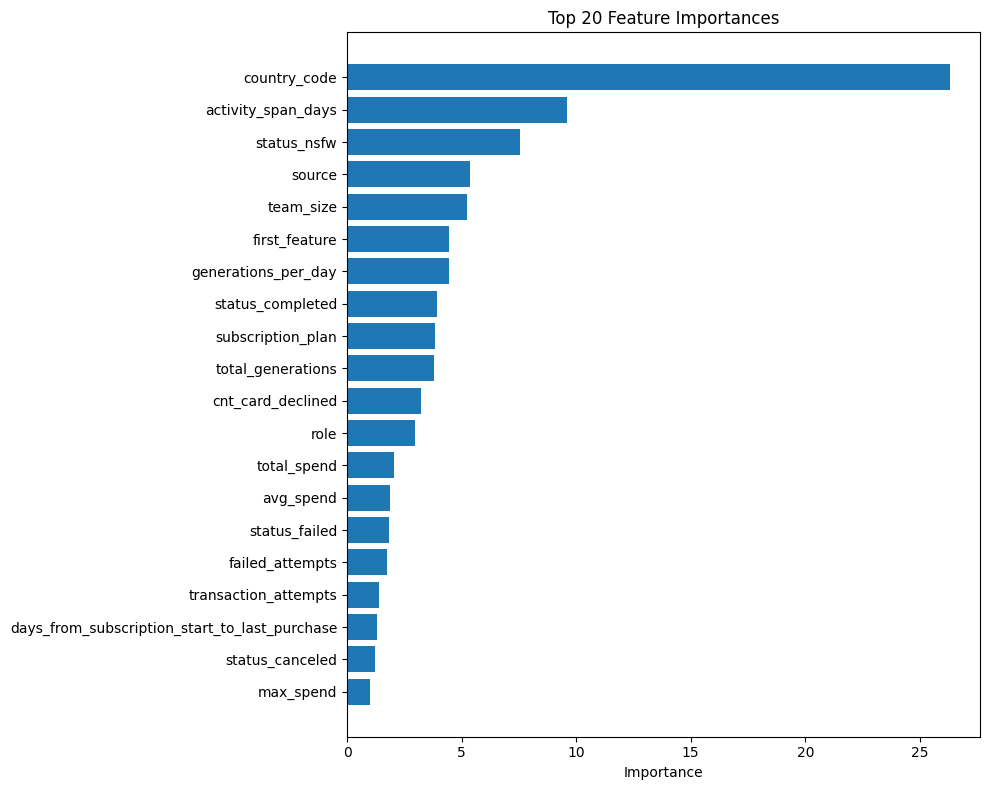

In [3]:
# ------------------------------
# 6. Feature importance
# ------------------------------
print("\n=== Feature Importance ===")
# Get feature names (exclude user_id, churn_status, subscription_start_date)
feature_names = X_full.columns.tolist()
importances = final_model.feature_importances_

# Create DataFrame and sort
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

# Print top 30 features
print(feat_imp.head(30).to_string(index=False))

# Optional: Plot top 20
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
top_n = 20
plt.barh(feat_imp['feature'][:top_n][::-1], feat_imp['importance'][:top_n][::-1])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()